In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *
from module_utils import *
from pathlib import Path
import ray 


# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)


# ray.init(
#     runtime_env={
#         "working_dir": "../utils",  # The primary working directory
#         "py_modules": [
#             os.path.abspath('../utils'),   # Additional module directory
#             os.path.abspath('../other_dir1'),  # Another directory
#             os.path.abspath('../other_dir2')   # Yet another directory
#         ]
#     },
#     ignore_reinit_error=True  # Ignore re-initialization error
# Add '../prova_LV' and '../utils' to the system path

# sys.path.append(os.path.abspath('../prova_LV'))
# sys.path.append(os.path.abspath('../utils'))

# # Initialize Ray with multiple directories in the runtime environment
# ray.init(
#     runtime_env={
#         "working_dir": "../prova_LV",  # Ensure the parent directory is the working directory
#         "py_modules": [
#             os.path.abspath('../utils')  # Include utils directory
#         ]
#     },
#     ignore_reinit_error=True  # Ignore re-initialization error
# )


# Add '../prova_LV' and '../utils' to the system path
# # # sys.path.append(os.path.abspath('../prova_LV'))
# # # sys.path.append(os.path.abspath('../utils'))

# # # # Initialize Ray with both directories in the runtime environment
# # # ray.init(
# # #     runtime_env={
# # #         "working_dir": "../prova_LV",  # Set the working directory to 'prova_LV'
# # #         "py_modules": [
# # #             os.path.abspath('../prova_LV'),  # Include 'prova_LV' directory
# # #             os.path.abspath('../utils')      # Include 'utils' directory
# # #         ]
# # #     },
# # #     ignore_reinit_error=True  # Ignore re-initialization error
# # # )

# Import the required modules
from module_utils import *
from Structure import * 

In [2]:

file_path = 'dataset_abcd_variationLLF.csv'

# [t, y_values_list[i][j, 0], y_values_list[i][j, 1], a_values[i],b_values[i],c_values[i],d_values[i]]
data_LF = np.genfromtxt(file_path, delimiter=',', dtype=None)

file_path = 'dataset_abcd_variationHF.csv'

data_HF = np.genfromtxt(file_path, delimiter=',', dtype=None)

model_list=[0]*len(np.unique(data_LF[:,-4]))


In [3]:
nlf=150
nhf=50
batch_size=[nlf,nhf]

# number of epochs 
Nepo = [1000,1500]

indexes_LF = np.where(np.diff(data_LF[:,-4]) != 0)[0] + 1
indexes_LF = np.insert(indexes_LF, 0, 0)
indexes_LF = np.append(indexes_LF, len(data_LF))


indexes_HF = np.where(np.diff(data_HF[:,-4]) != 0)[0] + 1
indexes_HF = np.insert(indexes_HF, 0, 0)
indexes_HF = np.append(indexes_HF, len(data_HF))


r2_HF_df = pandas.DataFrame(columns=['a','b','c','d','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['a','b','c','d','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['a','b','c','d','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['a','b','c','d','MSE'])  # dataframe which stores LF MSE



Folder '2_step_models' already exists.

The function training took 31.180465936660767 seconds.


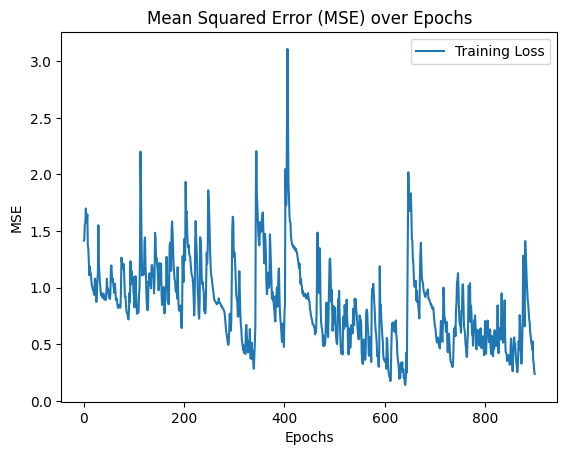

The function training took 47.63008260726929 seconds.


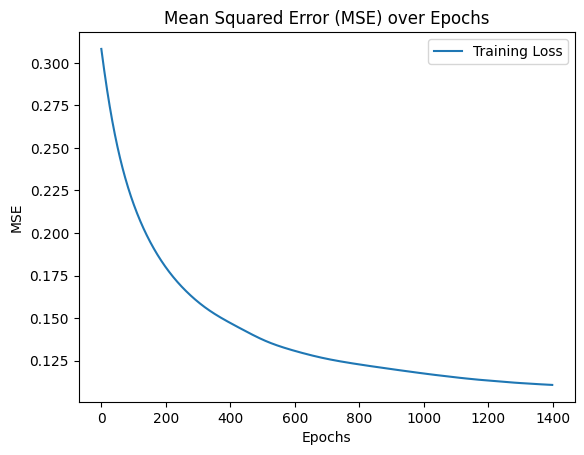

low fidelity NN
LF input
Test MSE: 0.20149137882389703
R^2: 0.960086229350135
HF input
Test MSE: 0.3057580776513524
R^2: 0.9297102756210025
Final model
Test MSE: 0.12934048737862286
R^2: 0.9702663384113267


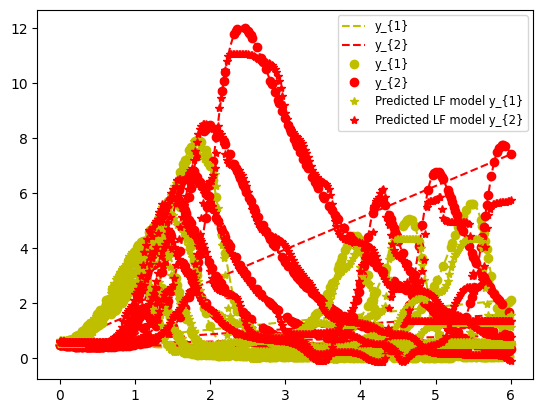

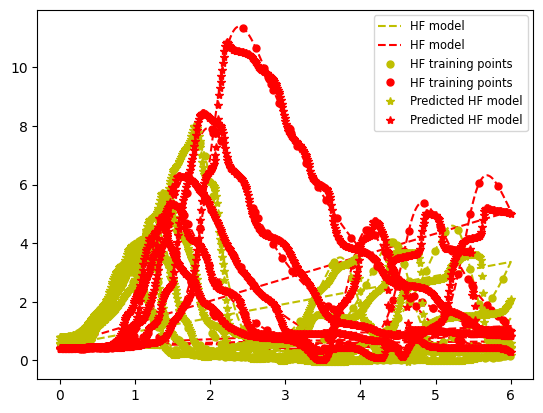

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_52888\3457067765.py:218: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_52888\3457067765.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_52888\3457067765.py:226: FutureWarning: The beha

Saving ...
     a    b    c    d       R2       mu
0  NaN  NaN  NaN  NaN  0.97027  0.01484
     a    b    c    d      MSE       mu       R2
0  NaN  NaN  NaN  NaN  0.12934  0.01484  0.97027


In [4]:
# Name of the folder
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
            
test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

data_HF_test=np.empty((0,data_HF.shape[1]))
data_HF_train=np.empty((0,data_HF.shape[1]))
data_LF_test=np.empty((0,data_LF.shape[1]))
data_LF_train=np.empty((0,data_LF.shape[1]))

for i in range(len(np.unique(data_LF[:,-4]))):

    #temp=normalization(data_HF[indexes_HF[i]:indexes_HF[i+1],:])
    temp=data_HF[indexes_HF[i]:indexes_HF[i+1],:]
    data_HF_test=np.append(data_HF_test,temp,axis=0)

    permutation = np.random.permutation(temp.shape[0]) #data_HF[indexes_HF[0]:indexes_HF[1],:].shape[0])
    data_HF_train = np.append(data_HF_train,temp[permutation,:][0:nhf,:],axis=0)

    #tempLF=normalization(data_LF[indexes_LF[i]:indexes_LF[i+1],:])
    tempLF=data_LF[indexes_LF[i]:indexes_LF[i+1],:]

    data_LF_test=np.append(data_LF_test,tempLF,axis=0)

    permutation = np.random.permutation(tempLF.shape[0]) #data_HF[indexes_HF[0]:indexes_HF[1],:].shape[0])
    data_LF_train = np.append(data_LF_train,tempLF[permutation,:][0:nlf,:],axis=0)


##########################      Neural Network     ##########################
K.clear_session()

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

# reproducibilty porpuse 
learning_rate = bestLF_params["lr"]
optimizer_type = bestLF_params["opt"]

# Fissa i parametri di ottimizzazione
if optimizer_type == "Adam":
    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
elif optimizer_type == "Nadam":
    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
elif optimizer_type == "Adamax":
    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
else:
    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")

# Multifidelity network 
names=["LF","HF"]
params=[bestLF_params, best_params]


input_LF_train=np.concatenate((data_LF_train[:, 0].reshape(-1,1), data_LF_train[:, 3:7]), axis=1)
input_HF_train=np.concatenate((data_HF_train[:, 0].reshape(-1,1), data_HF_train[:, 3:7]), axis=1)
data_train=[input_LF_train,input_HF_train]

output_LF_train=data_LF_train[:,1:3]
output_HF_train=data_HF_train[:,1:3]
output_train=[output_LF_train,output_HF_train]

input_LF_test=np.concatenate((data_LF_test[:, 0].reshape(-1,1), data_LF_test[:, 3:7]), axis=1)
input_HF_test= np.concatenate((data_HF_test[:, 0].reshape(-1,1), data_HF_test[:, 3:7]), axis=1)
data_test=[input_LF_test, input_HF_test]

output_LF_test=data_LF_test[:,1:3]
output_HF_test=data_HF_test[:,1:3]
output_test=[output_LF_test,output_HF_test]

            
model= NetworkFactory.build_network("2step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=False)

# low fidelity part of the network 
ULF = model.model_list[0].prediction(input_LF_train)
print("low fidelity NN")
print("LF input")
(test_mse_LF,r2_LF) = model.model_list[0].performance(input_LF_test,output_LF_test)
test_mse_LF_list.append(test_mse_LF)
r2_LF_list.append(r2_LF)
print("HF input")
_,_= model.model_list[0].performance(input_HF_test,output_HF_test)
# creation of the input of the second part of the 2 steps NN to study the high fidelity model
input_HF = np.concatenate(
    (input_HF_test,  model.model_list[0].prediction(input_HF_test)),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF

input_HF_train = np.concatenate(
    (input_HF_train,  model.model_list[0].prediction(input_HF_train)),axis=1
) 
# performance of the last part of the network
print("Final model")
(test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,output_HF_test)                
test_mse_HF_list.append(test_mse_HF)
r2_HF_list.append(r2_HF)
            
            
# plots of the model
plt.figure()
plt.plot(
data_LF_test[:, 0], data_LF_test[:,1], "y--", linewidth=1.5, label="y_{1}"
)
plt.plot(
data_LF_test[:, 0], data_LF_test[:,2], "r--", linewidth=1.5, label="y_{2}"
)

plt.plot(
data_LF_train[:, 0], data_LF_train[:,1], "yo", linewidth=1.5, label="y_{1}"
)
plt.plot(
data_LF_train[:, 0], data_LF_train[:,2], "ro", linewidth=1.5, label="y_{2}"
)

plt.plot(
data_LF_test[:, 0],
model.model_list[0].prediction(input_LF_test)[:,0],
"y*",
linewidth=3,
label="Predicted LF model y_{1}",
)
plt.plot(
data_LF_test[:, 0],
model.model_list[0].prediction(input_LF_test)[:,1],
"r*",
linewidth=3,
label="Predicted LF model y_{2}",
)          
plt.legend(prop={"size": 8.3})
plt.show()
            

plt.figure()
plt.plot(
data_HF_test[:,0], output_HF_test[:,0], "y--", linewidth=1.5, label="HF model"
)
plt.plot(
data_HF_test[:,0], output_HF_test[:,1], "r--", linewidth=1.5, label="HF model"
)

        
plt.plot(
data_HF_train[:,0],
output_HF_train[:,0],
"yo",
markersize=5,
label="HF training points",
)
plt.plot(
data_HF_train[:,0],
output_HF_train[:,1],
"ro",
markersize=5,
label="HF training points",
)
            
            
# order=np.argsort(data_LF_train[:,0])
            
# plt.plot(
# data_LF_train[order,0],
# data_LF_train[order,1],
# "y-",
# markersize=5,
# label="LF training points",
# )
# plt.plot(
# data_LF_train[order,0],
# data_LF_train[order,2],
# "r-",
# markersize=5,
# label="LF training points",
# )
# plt.plot(
# data_LF_train[order,0],
# data_LF_train[order,3],
# "g-",
# markersize=5,
# label="LF training points",
# )

plt.plot(
data_HF_test[:,0],
model.model_list[1].prediction(input_HF)[:,0],
"y*",
linewidth=3,
label="Predicted HF model",
)
plt.plot(
data_HF_test[:,0],
model.model_list[1].prediction(input_HF)[:,1],
"r*",
linewidth=3,
label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()
            
new_data = {'mu': np.unique(data_LF)[i]}

# DataFrame r2_LF_df
new_data['R2'] = r2_LF_list[-1]
r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

# DataFrame r2_HF_df
new_data['R2'] = r2_HF_list[-1]
r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)

# DataFrame mse_LF_df
new_data['MSE'] = test_mse_LF_list[-1]
mse_LF_df = pandas.concat([mse_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

# DataFrame mse_HF_df
new_data['MSE'] = test_mse_HF_list[-1]
mse_HF_df = pandas.concat([mse_HF_df, pandas.DataFrame([new_data])], ignore_index=True)

        
# save the model
model.save(str(np.unique(data_LF[:,-1])[i]),folder_path)
    

            
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

In [5]:
# # Add '../prova_LV' and '../utils' to the system path
# sys.path.append(os.path.abspath('../prova_LV'))
# sys.path.append(os.path.abspath('../utils'))

# # Initialize Ray with both directories in the runtime environment
# ray.init(
#     runtime_env={
#         "working_dir": os.path.abspath('../prova_LV'),  # Set the working directory to 'prova_LV'
#         "py_modules": [
#             os.path.abspath('../prova_LV'),  # Include 'prova_LV' directory
#             os.path.abspath('../utils')      # Include 'utils' directory
#         ]
#     },
#     ignore_reinit_error=True  # Ignore re-initialization error
# )


In [6]:
# true parameters
sigma_noise=[0.25]
n_data=[15,25]
parameters=np.array([2.,0.6,0.6,0.8])

mean_prior=np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])
# cov_linkelihood
sigma=1.5

# adaptive metropolis
rwmh_cov = np.eye(4)
#rmwh_scaling = 0.25
rwmh_adaptive = True
iterations =3000
burnin = 1500
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        print(f"noise {sigma_noise[noise]}")
        print(f"nb.data {n_data[n]}")


        t_eval=np.linspace(0.,6.,n_data[n]).reshape(-1,1)
# prior


        closest_indices= np.argmin( np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0, np.newaxis] - t_eval.T), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
        nearest_x=data_HF[closest_indices,0]
        y_obs=data_HF[closest_indices,1:3] # chekc se giusto

        estimate_MF=model.param_inverse(mean_prior, t_eval, levels=2, cov_prior=cov_prior, cov_noise=sigma_noise[noise], cov_likelihood=sigma**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MLDA")



noise 0.25
nb.data 15
(15, 2)
2
real values are [2.  0.6 0.6 0.8]
dim
4
[<tinyDA.posterior.Posterior object at 0x0000023360E86DE0>, <tinyDA.posterior.Posterior object at 0x0000023360E849E0>]
OK


c:\Users\Giacomo\miniconda3\Lib\site-packages\keras\src\saving\saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\Giacomo\miniconda3\Lib\site-packages\keras\src\saving\saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Sampling 2 chains in parallel


2024-07-22 04:30:44,678	INFO worker.py:1788 -- Started a local Ray instance.
(RemoteDAChain pid=236208) 2024-07-22 04:30:50.389068: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(RemoteDAChain pid=236208) 2024-07-22 04:30:52.815068: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(RemoteDAChain pid=236208) To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
(RemoteDAChain pid=236208) c:\Users\Giacomo\miniconda3\Lib\site-packages\keras\src\saving\saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimize

RayTaskError(TypeError): [36mray::RemoteDAChain.sample()[39m (pid=236208, ip=127.0.0.1, actor_id=a8a50b65168d80a5ca6792b501000000, repr=<tinyDA.ray.RemoteDAChain object at 0x000001B5374AC4D0>)
  File "python\ray\_raylet.pyx", line 1901, in ray._raylet.execute_task
  File "python\ray\_raylet.pyx", line 1842, in ray._raylet.execute_task.function_executor
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\_private\function_manager.py", line 691, in actor_method_executor
    return method(__ray_actor, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\util\tracing\tracing_helper.py", line 467, in _resume_span
    return method(self, *_args, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\ray.py", line 198, in sample
    super().sample(iterations, progressbar)
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\chain.py", line 322, in s

In [7]:
# true parameters
sigma_noise=[0.25]
n_data=[15,25]
parameters=np.array([2.,0.6,0.6,0.8])

mean_prior=np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])
# cov_linkelihood
sigma=1.5

# adaptive metropolis
rwmh_cov = np.eye(4)
#rmwh_scaling = 0.25
rwmh_adaptive = True
iterations =3000
burnin = 1500
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        print(f"noise {sigma_noise[noise]}")
        print(f"nb.data {n_data[n]}")


        t_eval=np.linspace(0.,6.,n_data[n]).reshape(-1,1)
# prior


        closest_indices= np.argmin( np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0, np.newaxis] - t_eval.T), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
        nearest_x=data_HF[closest_indices,0]
        y_obs=data_HF[closest_indices,1:3] # chekc se giusto

        estimate_MF=model.param_inverse(mean_prior, t_eval, levels=2, cov_prior=cov_prior, cov_noise=sigma_noise[noise], cov_likelihood=sigma**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="MLDA")



noise 0.25
nb.data 15
(15, 2)
2
real values are [2.  0.6 0.6 0.8]
dim
4
[<tinyDA.posterior.Posterior object at 0x0000023360E86D50>, <tinyDA.posterior.Posterior object at 0x00000233670FDC10>]
OK


2024-07-22 04:30:59,280	ERROR worker.py:409 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): ray::RemoteDAChain.sample() (pid=236960, ip=127.0.0.1, actor_id=798126f5cb4e3d157770c30e01000000, repr=<tinyDA.ray.RemoteDAChain object at 0x000001A8681A57C0>)
  File "python\ray\_raylet.pyx", line 1901, in ray._raylet.execute_task
  File "python\ray\_raylet.pyx", line 1842, in ray._raylet.execute_task.function_executor
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\_private\function_manager.py", line 691, in actor_method_executor
    return method(__ray_actor, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\util\tracing\tracing_helper.py", line 467, in _resume_span
    return method(self, *_args, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\ray.py", line 198, in sample
    super().sample(iterations, progressbar)
  File "c

Sampling 2 chains in parallel


2024-07-22 04:31:26,314	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


(RemoteDAChain pid=272028) 2024-07-22 04:31:30.206143: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(RemoteDAChain pid=272028) 2024-07-22 04:31:32.758415: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
(RemoteDAChain pid=272028) To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
(RemoteDAChain pid=272028) c:\Users\Giacomo\miniconda3\Lib\site-packages\keras\src\saving\saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 32 variables. 
(RemoteDAChain pid=272028)   saveable.load_own_variables

RayTaskError(TypeError): [36mray::RemoteDAChain.sample()[39m (pid=272028, ip=127.0.0.1, actor_id=2800bced5cf2481a6291cdf101000000, repr=<tinyDA.ray.RemoteDAChain object at 0x00000151F533E7E0>)
  File "python\ray\_raylet.pyx", line 1901, in ray._raylet.execute_task
  File "python\ray\_raylet.pyx", line 1842, in ray._raylet.execute_task.function_executor
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\_private\function_manager.py", line 691, in actor_method_executor
    return method(__ray_actor, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\util\tracing\tracing_helper.py", line 467, in _resume_span
    return method(self, *_args, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\ray.py", line 198, in sample
    super().sample(iterations, progressbar)
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\chain.py", line 322, in s

In [8]:
# true parameters
sigma_noise=[0.25]
n_data=[15,25]
parameters=np.array([2.,0.6,0.6,0.8])

mean_prior=np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])
# cov_linkelihood
sigma=1.5

# adaptive metropolis
rwmh_cov = np.eye(4)
#rmwh_scaling = 0.25
rwmh_adaptive = True
iterations =3000
burnin = 1500
n_chains=2

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        print(f"noise {sigma_noise[noise]}")
        print(f"nb.data {n_data[n]}")


        t_eval=np.linspace(0.,6.,n_data[n]).reshape(-1,1)
# prior


        closest_indices= np.argmin( np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0, np.newaxis] - t_eval.T), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
        nearest_x=data_HF[closest_indices,0]
        y_obs=data_HF[closest_indices,1:3] # chekc se giusto

        estimate_MF=model.param_inverse(mean_prior, t_eval, levels=1, cov_prior=cov_prior, cov_noise=sigma_noise[noise], cov_likelihood=sigma**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="AM")



noise 0.25
nb.data 15
(15, 2)
real values are [2.  0.6 0.6 0.8]
dim
4
OK


TypeError: 'Posterior' object is not subscriptable

In [9]:
# true parameters
sigma_noise=[0.5,1.]
n_data=[5,15,25,50]
parameters=np.array([2.,0.6,0.6,0.8])

mean_prior=np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])
# cov_linkelihood
sigma=1.5

# adaptive metropolis
rwmh_cov = np.eye(4)
#rmwh_scaling = 0.25
rwmh_adaptive = True
iterations =30
burnin = 15
n_chains=6

for noise in range(len(sigma_noise)):
    for n in range(len(n_data)):
        print(f"noise {sigma_noise[noise]}")
        print(f"nb.data {n_data[n]}")


        t_eval=np.linspace(0.,6.,n_data[n]).reshape(-1,1)
# prior

        # to be modified depending on th eparameters combination that youi are choosing
        closest_indices= np.argmin( np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0, np.newaxis] - t_eval.T), axis=0)#    np.argmin(np.abs(data_HF[indexes_HF[0]:indexes_HF[1],0] - t_eval))
        nearest_x=data_HF[closest_indices,0]
        y_obs=data_HF[closest_indices,1:3] # chekc se giusto

        estimate_MF=model.param_inverse(mean_prior, t_eval, cov_prior=cov_prior, cov_noise=sigma_noise[noise], cov_likelihood=sigma**2*np.eye(t_eval.shape[0]), y_obs=y_obs,x_real=parameters, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rwmh_adaptive=rwmh_adaptive,algo="AM")



noise 0.5
nb.data 5
(5, 2)
real values are [2.  0.6 0.6 0.8]
dim
4
OK


TypeError: 'Posterior' object is not subscriptable